Title: frequency_analysis.ipynb

Author: Quin Aicken Davies

Date: 24/11/2025

Description: Perform a frequency analysis on the given dataset

In [1]:
import numpy as np
import pandas as pd
from Pyriod import Pyriod
import lightkurve as lk

from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.nddata import NDData
from astropy.modeling.fitting import LevMarLSQFitter

# from photutils.detection import DAOStarFinder
# from photutils.psf import extract_stars, EPSFStars, EPSFBuilder, EPSFModel, PSFPhotometry, SourceGrouper, IterativePSFPhotometry
# from photutils.background import MMMBackground, LocalBackground

# from tqdm import tqdm

# import warnings
# from astropy.utils.exceptions import AstropyUserWarning

# from astropy.wcs import FITSFixedWarning

# warnings.filterwarnings('ignore', category=FITSFixedWarning)

# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings('ignore', category=AstropyUserWarning,
#                         message='.*fit.*not have converged.*')
# warnings.filterwarnings('ignore', category=AstropyUserWarning,
#                         message='.*fitting region extends beyond the star cutout image.*')
# warnings.filterwarnings("ignore", category=AstropyUserWarning, message=".*data contains invalid values.*")
import glob
import os
import matplotlib.pyplot as plt
# %matplotlib widget
# %matplotlib notebook
%matplotlib inline


In [2]:
"""Import the data for lightcurve analysis"""
data = pd.read_csv('E:\Summer 2025 Data\Summer_Project\Measurements.xls', delimiter = '\t')
target_data = data.iloc[:92]  # first 92 rows
"""Extract the object for plotting"""
zz_Psc_flux = target_data['rel_flux_T1']
zz_Psc_time = target_data['JD_UTC']

# create and clean arrays, downsample if very large before making LightCurve
time = np.asarray(zz_Psc_time, dtype=float)
flux = np.asarray(zz_Psc_flux, dtype=float)
mask = np.isfinite(time) & np.isfinite(flux)
time, flux = time[mask], flux[mask]

# limit points to avoid huge messages to the frontend
max_points = 20000
if len(time) > max_points:
    idx = np.linspace(0, len(time) - 1, max_points).astype(int)
    time, flux = time[idx], flux[idx]

"""Create LightCurve object and pass to Pyriod"""
lc = lk.LightCurve(time=time, flux=flux)
time_array = lc.time.value   # removes units
flux_array = lc.flux.value   # removes units

# from Pyriod import Pyriod
# # Pass these to Pyriod
# pyriod = Pyriod(lc)
# # pyriod.Pyriod()

# pyriod.TimeSeries()      # Light curve
# pyriod.Periodogram()     # Periodogram
# pyriod.Signals()         # Fitted signals (after adding)

e:\Summer 2025 Data\Summer_Project\.venv\Lib\site-packages\astropy\timeseries\periodograms\lombscargle\_statistics.py:243: RuntimeWarning: invalid value encountered in sqrt
  Teff = np.sqrt(4 * np.pi * Dt)  # Effective baseline


   rank   frequency    period     power  fap_baluev  fap_bootstrap       fap
0     1  112.081754  0.008922  0.227595         NaN       0.003992  0.003992
1     2  145.046975  0.006894  0.173975         NaN       0.025948  0.025948


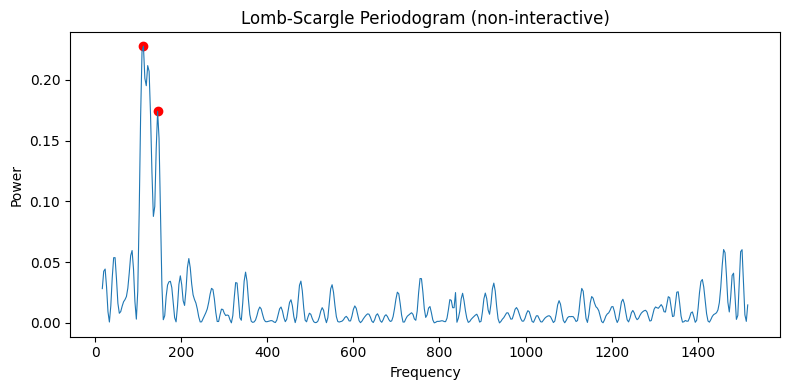

In [3]:
"""Use lombscargle instead of Pyriod"""
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

# use the cleaned arrays (time_array, flux_array) created earlier
t = time_array
y = flux_array

# compute periodogram (use 'standard' normalization for analytic FAPs)
ls = LombScargle(t, y, normalization='standard')
baseline = t.max() - t.min()
frequency, power = ls.autopower(nyquist_factor=2, minimum_frequency=1.0 / baseline)

# find peaks
thresh = np.mean(power) + 2 * np.std(power)
peaks, props = find_peaks(power, height=thresh, distance=5)

# prepare results and compute FAPs
results = []
top_idxs = np.argsort(power[peaks])[::-1][:10]  # top 10 peaks (by power)
n_bootstrap = 500  # increase if you want smoother bootstrap FAP estimates

# Precompute bootstrap max powers only if needed (lazy)
bootstrap_max_powers = None

for rank, pidx in enumerate(top_idxs, start=1):
    idx = peaks[pidx]
    freq_peak = frequency[idx]
    period_peak = 1.0 / freq_peak
    pwr = power[idx]

    # try analytic Baluev FAP (specify maximum_frequency)
    fap_baluev = None
    try:
        fap_baluev = ls.false_alarm_probability(pwr, method='baluev', maximum_frequency=frequency.max())
    except Exception:
        fap_baluev = None

    # if analytic returned NaN or failed, do bootstrap
    fap_boot = None
    if fap_baluev is None or (isinstance(fap_baluev, float) and np.isnan(fap_baluev)):
        # compute bootstrap distribution of max periodogram power (do once)
        if bootstrap_max_powers is None:
            bootstrap_max_powers = np.empty(n_bootstrap)
            for i in range(n_bootstrap):
                y_sh = np.random.permutation(y)            # shuffle data values (breaks signal)
                ls_sh = LombScargle(t, y_sh, normalization='standard')
                p_sh = ls_sh.power(frequency)
                bootstrap_max_powers[i] = p_sh.max()
        # empirical FAP: fraction of bootstraps whose max >= observed peak power
        fap_boot = (np.sum(bootstrap_max_powers >= pwr) + 1) / (n_bootstrap + 1)

    # choose reported fap (prefer analytic if valid)
    fap_report = fap_baluev if (fap_baluev is not None and not np.isnan(fap_baluev)) else fap_boot

    results.append({
        'rank': rank,
        'frequency': float(freq_peak),
        'period': float(period_peak),
        'power': float(pwr),
        'fap_baluev': float(fap_baluev) if (fap_baluev is not None and not np.isnan(fap_baluev)) else np.nan,
        'fap_bootstrap': float(fap_boot) if fap_boot is not None else np.nan,
        'fap': float(fap_report) if fap_report is not None else np.nan
    })

df_peaks = pd.DataFrame(results)
print(df_peaks)

# save outputs
# df_peaks.to_csv('periodogram_peaks_with_fap.csv', index=False)
# np.savetxt('periodogram_freq_power.txt', np.column_stack([frequency, power]), header='frequency power')

# non-interactive plot (inline)
plt.figure(figsize=(8,4))
plt.plot(frequency, power, lw=0.8)
plt.scatter([r['frequency'] for r in results],[r['power'] for r in results], color='r')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('Lomb-Scargle Periodogram (non-interactive)')
plt.tight_layout()
plt.savefig('periodogram.png', dpi=150)
plt.show()

iter 1: f = 112.081754  period = 0.008922  amp = 0.0060018  offset = 0.31975
iter 2: f = 128.564365  period = 0.007778  amp = 0.0049939  offset = 2.6174e-05
iter 3: f = 145.046975  period = 0.006894  amp = 0.0046559  offset = 6.493e-05
iter 4: f = 46.151310  period = 0.021668  amp = 0.0031627  offset = 0.00032214
iter 5: f = 217.570463  period = 0.004596  amp = 0.0028921  offset = -0.00010691
iter 6: f = 349.431350  period = 0.002862  amp = 0.002264  offset = -2.2171e-05
iter 7: f = 1410.911488  period = 0.000709  amp = 0.0022711  offset = -2.2259e-05
     frequency    period         a         b  amplitude  phase_rad    offset
0   112.081754  0.008922 -0.002217 -0.005367   0.005807  -1.962520  0.319997
1   128.564365  0.007778 -0.002191  0.004698   0.005184   2.007204  0.319997
2   145.046975  0.006894  0.004381  0.000898   0.004472   0.202068  0.319997
3    46.151310  0.021668  0.002300  0.001905   0.002987   0.691867  0.319997
4   217.570463  0.004596  0.002612 -0.000616   0.002684  

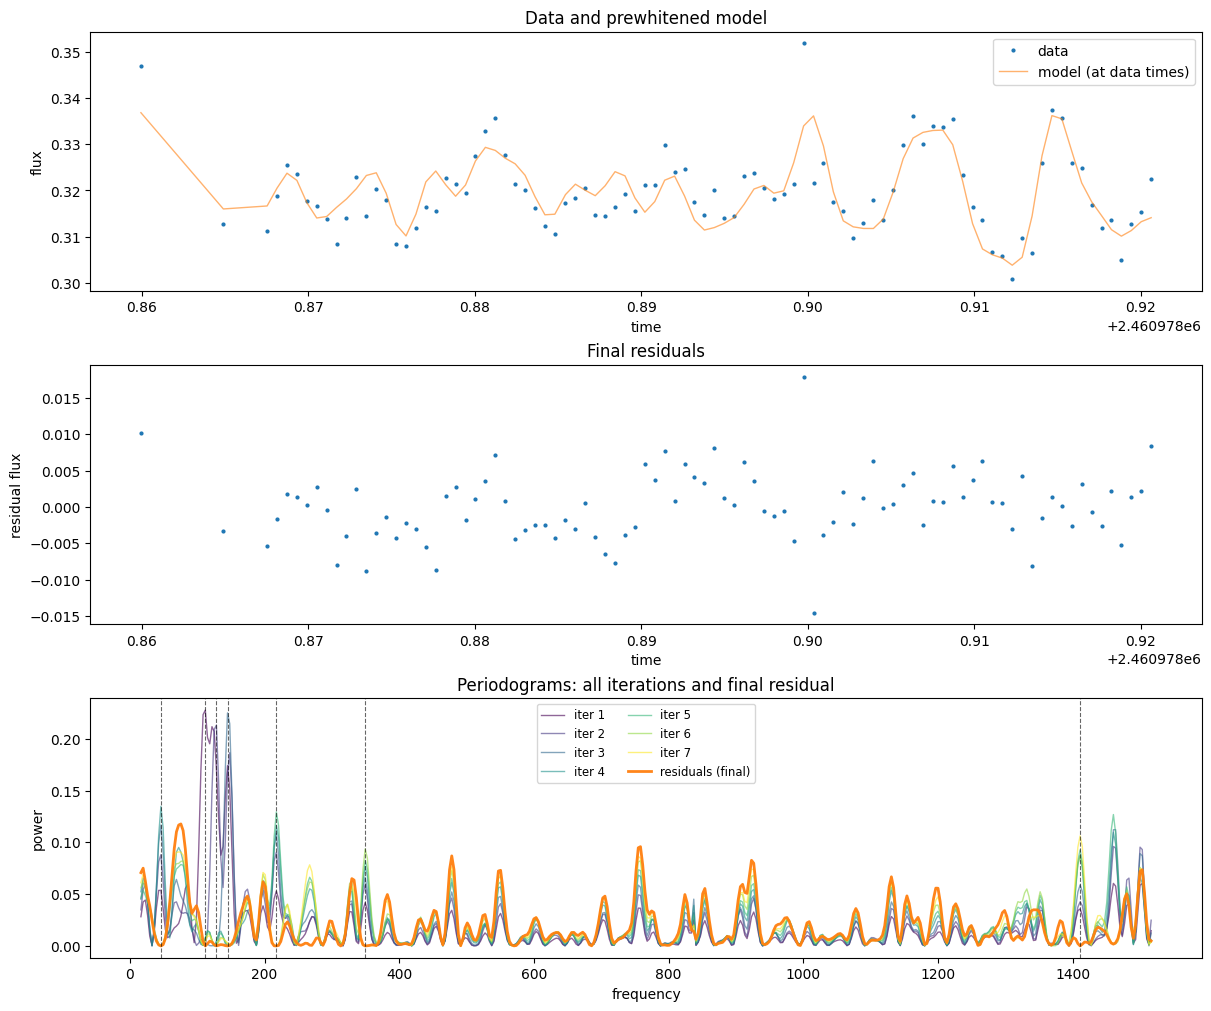

In [7]:
"""Perform some prewhitening iterations, default 3"""

#Inputs expected from previous cells
# Iteration numbers
n_iter = 7
#Create a copy of the data to work on
residual = y.copy()
found_freqs = []

# store intermediate periodograms if wanted
periodograms = []

for it in range(n_iter):
    ls_res = LombScargle(t, residual, normalization='standard')
    freq_res, power_res = ls_res.autopower(nyquist_factor=2, minimum_frequency=1.0 / baseline)
    periodograms.append((freq_res.copy(), power_res.copy()))

    # choose highest peak frequency
    peak_idx = np.argmax(power_res)
    f_peak = float(freq_res[peak_idx])
    found_freqs.append(f_peak)

    # linear fit for cos and sin and constant: residual ~ a*cos(omega t) + b*sin(omega t) + c
    omega = 2.0 * np.pi * f_peak
    X = np.vstack([np.cos(omega * t), np.sin(omega * t), np.ones_like(t)]).T
    coeffs, *_ = np.linalg.lstsq(X, residual, rcond=None)
    a, b, c = coeffs
    comp_model = X.dot(coeffs)

    # subtract component
    residual = residual - comp_model

    print(f"iter {it+1}: f = {f_peak:.6f}  period = {1.0/f_peak:.6f}  amp = {np.hypot(a,b):.5g}  offset = {c:.5g}")

# final combined fit using the found frequencies (fit all at once to original data)
if len(found_freqs) == 0:
    raise RuntimeError("No frequencies found; reduce threshold or increase frequency resolution.")

# build design matrix with all components + constant
cols = []
for f in found_freqs:
    omega = 2.0 * np.pi * f
    cols.append(np.cos(omega * t))
    cols.append(np.sin(omega * t))
cols.append(np.ones_like(t))
X_all = np.vstack(cols).T
coeffs_all, *_ = np.linalg.lstsq(X_all, y, rcond=None)

# unpack coefficients and build model
model_total = X_all.dot(coeffs_all)
residual_final = y - model_total

# derive component amplitudes/phases/offset
components = []
for i, f in enumerate(found_freqs):
    a = coeffs_all[2*i]
    b = coeffs_all[2*i + 1]
    amp = np.hypot(a, b)
    phase = np.arctan2(b, a)            # phase so that component = amp * cos(omega t - phase)
    components.append({'frequency': float(f),
                       'period': float(1.0/f),
                       'a': float(a),
                       'b': float(b),
                       'amplitude': float(amp),
                       'phase_rad': float(phase)})

# constant offset is last coeff
offset = float(coeffs_all[-1])

# save components
df_comp = pd.DataFrame(components)
df_comp['offset'] = offset
# df_comp.to_csv('prewhitening_components.csv', index=False)
# print("\nSaved prewhitening_components.csv")
print(df_comp)

"""plots: data vs model, residuals, periodograms before/after"""
fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

# subplot 1: data + model
axes[0].plot(t, y, '.', ms=4, label='data')
axes[0].plot(t, model_total, '-', lw=1.0, alpha=0.6, label='model (at data times)')
axes[0].set_xlabel('time')
axes[0].set_ylabel('flux')
axes[0].legend()
axes[0].set_title('Data and prewhitened model')

# subplot 2: residuals
axes[1].plot(t, residual_final, '.', ms=4)
axes[1].set_xlabel('time')
axes[1].set_ylabel('residual flux')
axes[1].set_title('Final residuals')

# subplot 3: periodograms (all iterations + final)
N = len(periodograms)
if N == 0:
    axes[2].text(0.5, 0.5, 'no periodograms recorded', ha='center')
else:
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, N))
    for i, (f_i, p_i) in enumerate(periodograms):
        axes[2].plot(f_i, p_i, color=colors[i], alpha=0.6, lw=1.0, label=f'iter {i+1}')
    ls_final = LombScargle(t, residual_final, normalization='standard')
    freq_r, power_r = ls_final.autopower(nyquist_factor=2, minimum_frequency=1.0 / baseline)
    axes[2].plot(freq_r, power_r, color='C1', lw=2.0, alpha=0.95, label='residuals (final)')
    for ff in found_freqs:
        axes[2].axvline(ff, color='k', ls='--', lw=0.8, alpha=0.6)
    axes[2].set_xlabel('frequency')
    axes[2].set_ylabel('power')
    axes[2].legend(ncol=2, fontsize='small')
    axes[2].set_title('Periodograms: all iterations and final residual')

# save final arrays
# np.savetxt('model_vs_time.txt', np.column_stack([t, y, model_total, residual_final]),
        #    header='time data model residual')

# optional: print FAPs for final components using LombScargle on original data
# ls_orig = LombScargle(t, y, normalization='standard')
# fap_list = []
# for comp in components:
#     f = comp['frequency']
#     # compute power at that frequency
#     pwr = ls_orig.power(f)
#     # analytic fap (baluev) try
#     try:
#         fap_b = ls_orig.false_alarm_probability(pwr, method='baluev', maximum_frequency=freq0.max())
#     except Exception:
#         fap_b = np.nan
#     fap_list.append({'frequency': f, 'power': float(pwr), 'fap_baluev': float(fap_b)})
# # df_fap = pd.DataFrame(fap_list)
# # df_fap.to_csv('component_faps.csv', index=False)
# print("Saved component_faps.csv")